<a href="https://colab.research.google.com/github/JakeOh/202605_BD57/blob/main/lab_python/da05_seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# tips 데이터프레임

In [2]:
tips = sns.load_dataset(name='tips')

In [3]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


# Box Plot

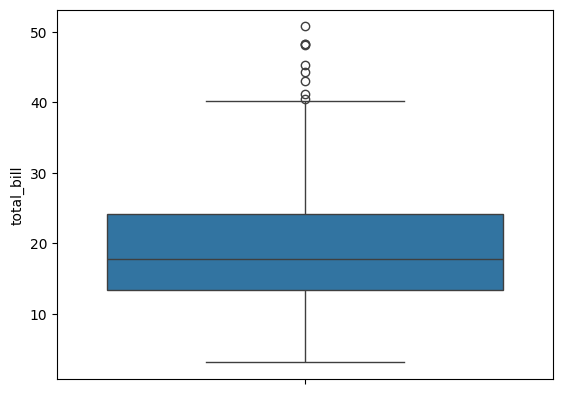

In [8]:
# total_bill box plot
sns.boxplot(data=tips, y='total_bill')
plt.show()

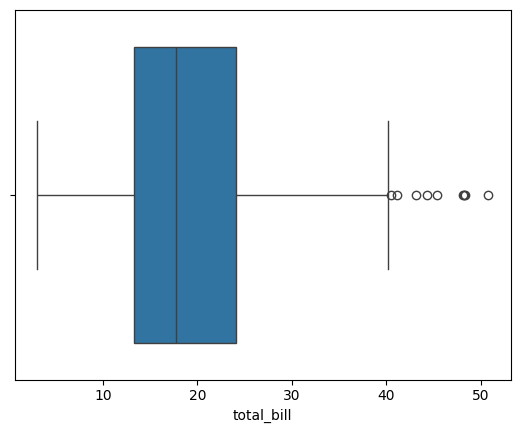

In [9]:
sns.boxplot(data=tips, x='total_bill')
plt.show()

## 성별 tip의 box plot

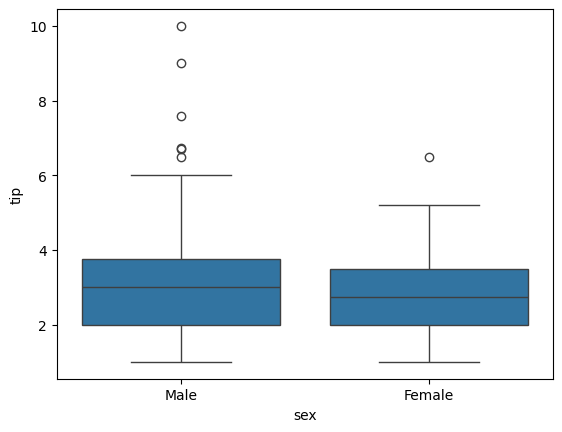

In [10]:
sns.boxplot(data=tips, x='sex', y='tip')
plt.show()

In [12]:
tips.groupby(by='sex', observed=True).tip.describe()

,count,mean,std,min,25%,50%,75%,max
sex,,,,,,,,
Male,157.0,3.089618,1.489102,1.0,2.0,3.00,3.76,10.0
Female,87.0,2.833448,1.159495,1.0,2.0,2.75,3.50,6.5


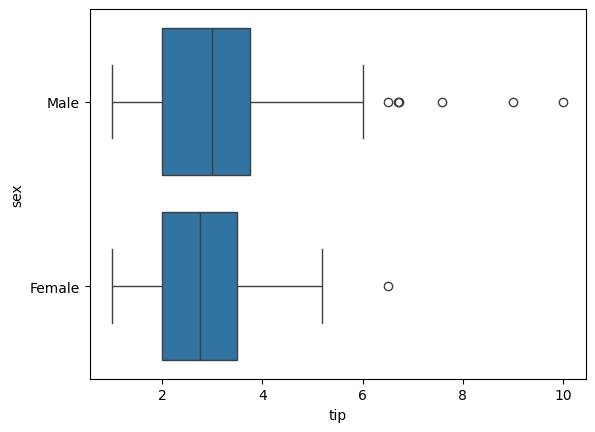

In [13]:
sns.boxplot(data=tips, x='tip', y='sex')
plt.show()

## 요일별 tip box plot

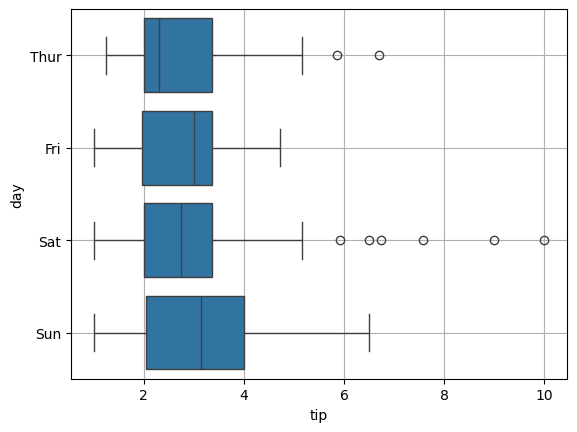

In [15]:
sns.boxplot(data=tips, x='tip', y='day')
plt.grid()
plt.show()

## 요일별 성별 tip box plot

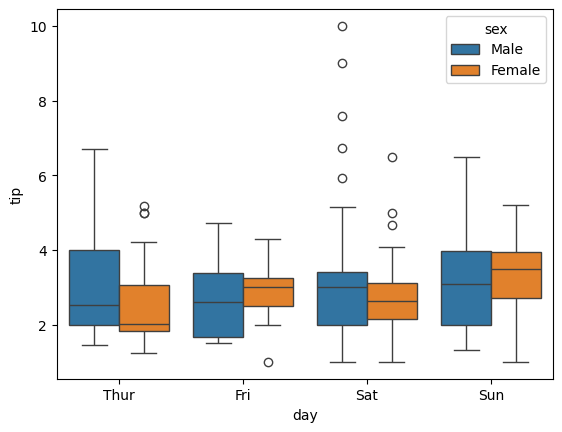

In [16]:
sns.boxplot(data=tips, x='day', y='tip', hue='sex')
plt.show()

In [18]:
tips.groupby(by=['day', 'sex'], observed=True).tip.describe()

count      mean       std   min     25%    50%     75%    max
day  sex                                                                  
Thur Male     30.0  2.980333  1.353734  1.44  2.0000  2.530  4.0000   6.70
     Female   32.0  2.575625  1.109286  1.25  1.8225  2.005  3.0575   5.17
Fri  Male     10.0  2.693000  1.136428  1.50  1.6650  2.600  3.3750   4.73
     Female    9.0  2.781111  0.938862  1.00  2.5000  3.000  3.2500   4.30
Sat  Male     59.0  3.083898  1.791360  1.00  2.0000  3.000  3.4000  10.00
     Female   28.0  2.801786  1.234480  1.00  2.1500  2.625  3.1025   6.50
Sun  Male     58.0  3.220345  1.271172  1.32  2.0000  3.085  3.9800   6.50
     Female   18.0  3.367222  1.136775  1.01  2.7075  3.500  3.9375   5.20

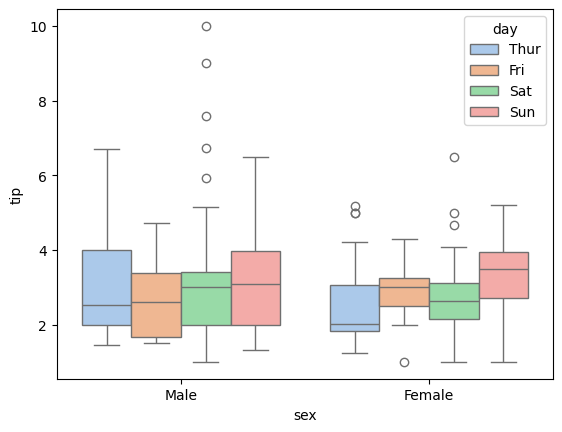

In [20]:
sns.boxplot(data=tips, x='sex', y='tip', hue='day', palette='pastel')
plt.show()

## 2개 이상의 Axes 사용하기

Figure를 2개의 Axes(nrows=1, ncols=2)로 구분, 각각의 Axes에 성별 tip, 시간별 tip box plot.

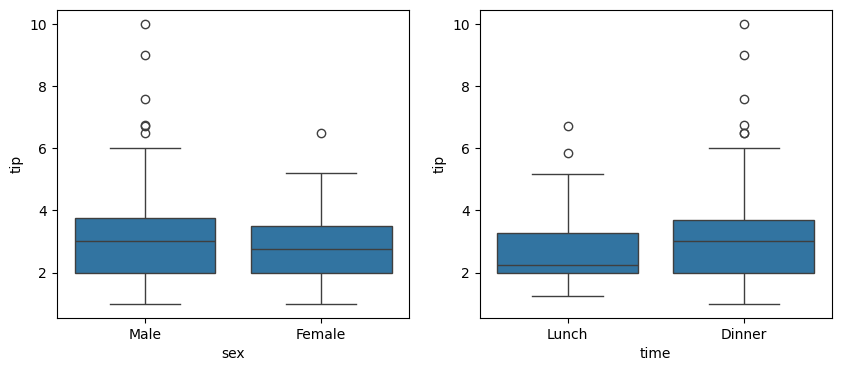

In [26]:
fig, axes = plt.subplots(ncols=2, figsize=(10, 4))

# axes[0]에 성별 tip box plot
sns.boxplot(data=tips, x='sex', y='tip', ax=axes[0])

# axex[1]에 시간별 tip box plot
sns.boxplot(data=tips, x='time', y='tip', ax=axes[1])

plt.show()

# Histogram

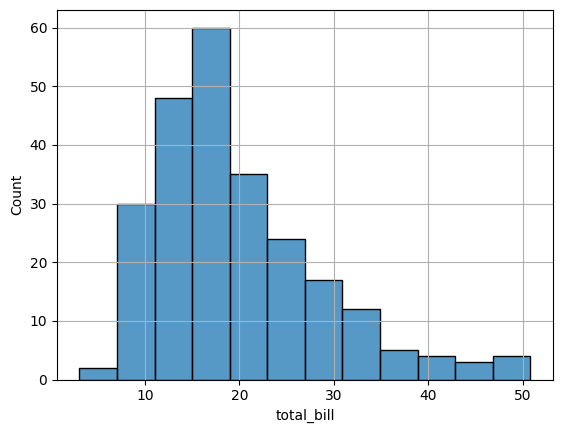

In [31]:
sns.histplot(data=tips, x='total_bill', bins=12)
plt.grid()
plt.show()

Figure를 2개 Axes(nrow=2, ncol=1)로 나누고, 위에는 tip box plot 가로방향으로, 아래쪽에는 tip histogram 그려보세요.

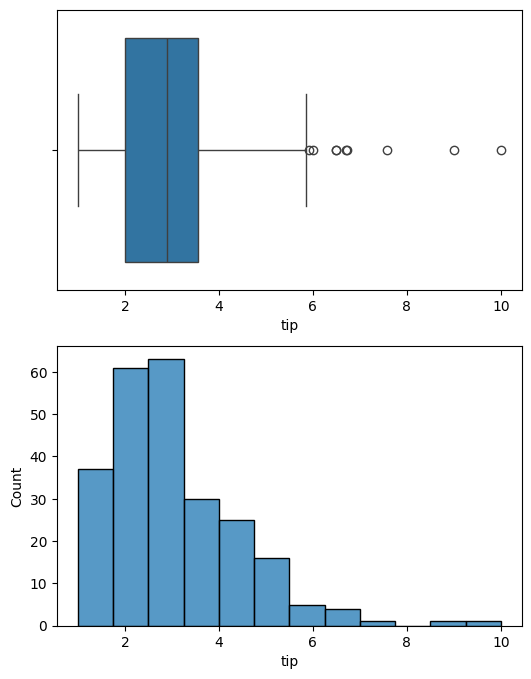

In [38]:
fig, axes = plt.subplots(nrows=2, figsize=(6, 8))

# axes[0]에 tip box plot
sns.boxplot(data=tips, x='tip', ax=axes[0])

# axes[1]에 tip histogram
sns.histplot(data=tips, x='tip', ax=axes[1], bins=12)

plt.show()

# 막대 그래프

## `countplot()` 함수

카테고리(범주) 변수의 빈도수를 막대로 시각화.

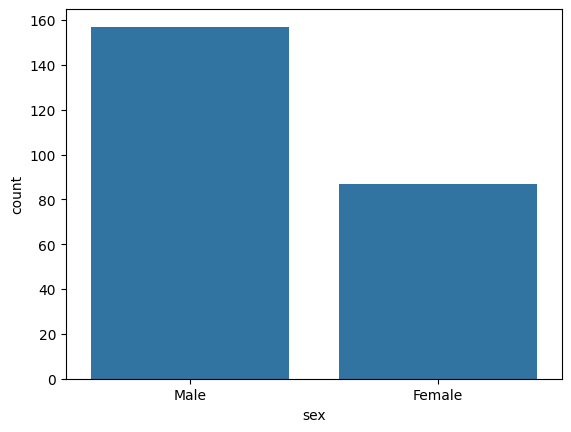

In [41]:
sns.countplot(data=tips, x='sex')
plt.show()

In [42]:
tips.sex.value_counts()

,count
sex,
Male,157
Female,87


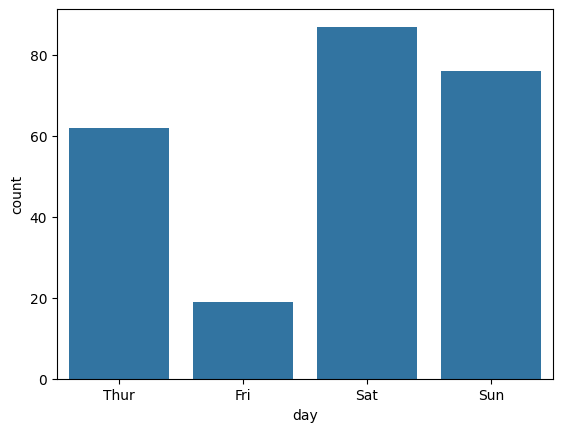

In [43]:
# 요일 빈도수
sns.countplot(data=tips, x='day')
plt.show()

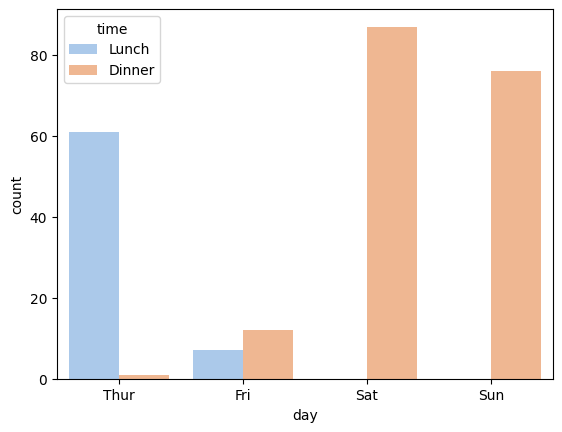

In [45]:
# 요일별 시간별 빈도수
sns.countplot(data=tips, x='day', hue='time', palette='pastel')
plt.show()

In [49]:
tips.groupby(by=['day', 'time'], observed=False).time.count()

day   time  
Thur  Lunch     61
      Dinner     1
Fri   Lunch      7
      Dinner    12
Sat   Lunch      0
      Dinner    87
Sun   Lunch      0
      Dinner    76
Name: time, dtype: int64